In [1]:

import numpy as np
from matplotlib import pyplot as plt
from dataclasses import dataclass
from echospec.utils.parameters import Parameters
from echospec.experiments.spectroscopy_vs_amplitude import AmplitudeSweepSpectroscopy, OptionsSpectroscopy2d
from echospec.utils.units import Units as u

from echospec.simulation.torry import find_fwhm_vec_vs_rabi
plt.style.use("paper.mplstyle")


import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec


Duplicate key in file 'paper.mplstyle', line 40 ('lines.linewidth     : 0.5')
Duplicate key in file 'paper.mplstyle', line 41 ('lines.markersize    : 4')
Bad value in file 'paper.mplstyle', line 17 ('font.size: 7,'): Key font.size: Could not convert '7,' to float
Bad value in file 'paper.mplstyle', line 18 ('axes.labelsize: 7,'): Key axes.labelsize: 7, is not a valid font size. Valid font sizes are xx-small, x-small, small, medium, large, x-large, xx-large, smaller, larger.
Bad value in file 'paper.mplstyle', line 19 ('xtick.labelsize: 6,'): Key xtick.labelsize: 6, is not a valid font size. Valid font sizes are xx-small, x-small, small, medium, large, x-large, xx-large, smaller, larger.
Bad value in file 'paper.mplstyle', line 20 ('ytick.labelsize: 6,'): Key ytick.labelsize: 6, is not a valid font size. Valid font sizes are xx-small, x-small, small, medium, large, x-large, xx-large, smaller, larger.
Bad value in file 'paper.mplstyle', line 21 ('legend.fontsize: 6,'): Key legend.fontsiz

1.99999980000002e-05


In [2]:
def run_spectroscopy(
    *,
    amplitudes,
    detunings,
    eco_pulse: bool,
    noise: float,
    num_time_points: int = 1000,
):
    options = OptionsSpectroscopy2d(
        plot=True,
        num_time_points=num_time_points,
        noise=noise,
    )

    params = Parameters()
    params.eco_pulse = eco_pulse
    params.cutoff = 0.99

    experiment = AmplitudeSweepSpectroscopy(
        amplitudes=amplitudes,
        detunings=detunings,
        params=params,
        options=options,
    )

    return experiment.run()

Amplitude sweep:   0%|          | 0/10 [00:00<?, ?Ω/s]

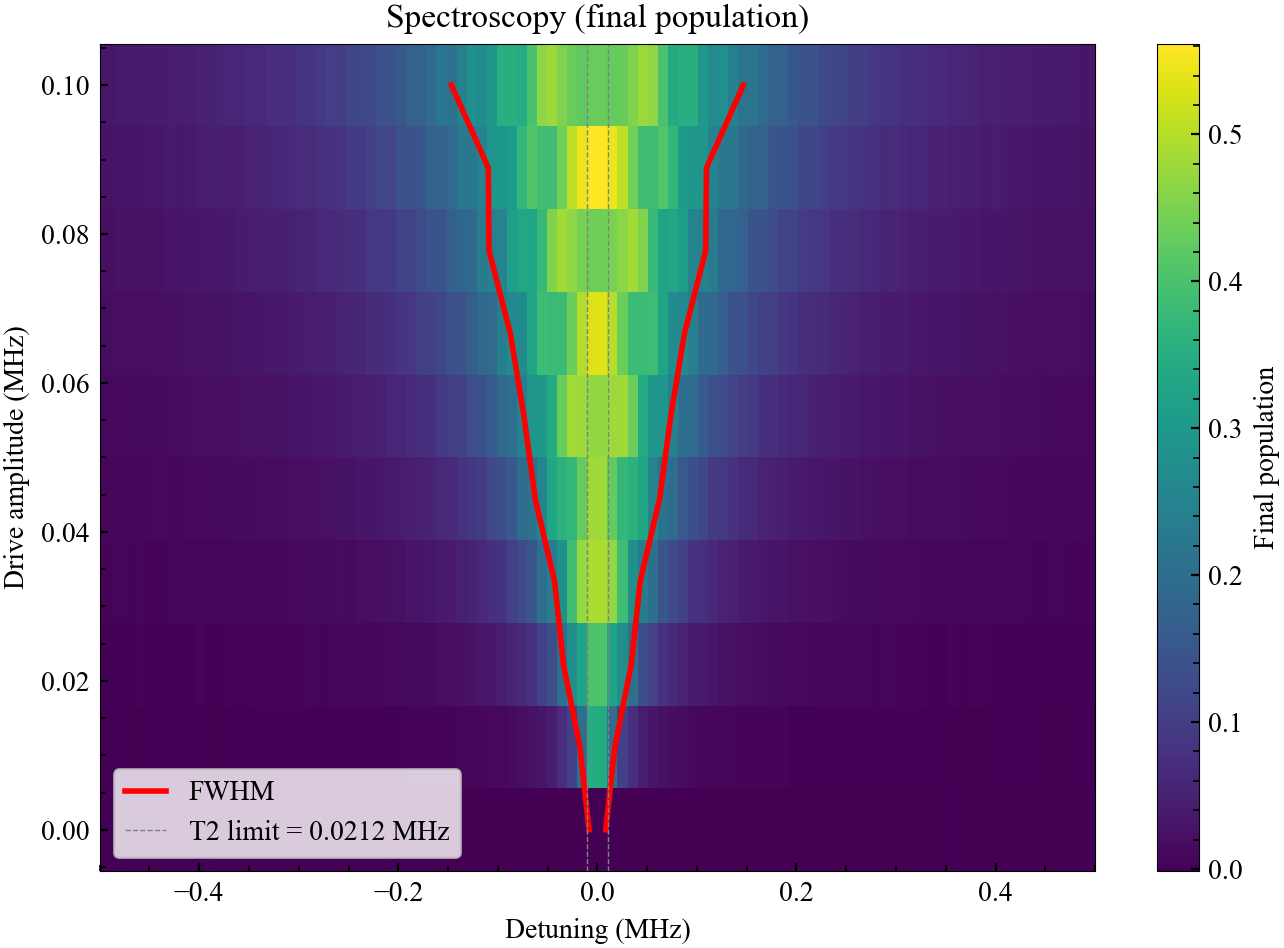

In [3]:
results = {"1": run_spectroscopy(amplitudes=np.linspace(0, 0.1, 10)*2*np.pi*1e6, detunings=np.linspace(-0.5, 0.5, 100)*2*np.pi*1e6, eco_pulse=False, noise=1e-3,)}

In [4]:
def const_run_length(
    *,
    length = 1e-6,
):
    options = OptionsSpectroscopy2d(
        plot=False,
        num_time_points=1000,
        noise=0,
    )
    params = Parameters()
    params.eco_pulse = False
    params.cutoff = 0.99
    params.pulse_length = length  # Use the passed length parameter
    
    
    max_detuning = 1/length*2*np.pi*2 + params.T2_limit*2*np.pi*2 # Set max_detuning to a constant value (e.g., 0.5 times the Fourier limit)
    
    experiment = AmplitudeSweepSpectroscopy(
        amplitudes=np.linspace(0, 0.1, 10)*2*np.pi*1e6,
        detunings=np.linspace(-max_detuning, max_detuning, 100),
        params=params,
        options=options,
    )
    result = experiment.run()
    return result.fwhm_map




In [5]:
lengths = np.linspace(0.05, 200, 300)*1e-6

# maps = []
# for length in lengths:
#     map = const_run_length(length=length)
#     maps.append(map[1:])

# np.save("length_scan_maps.npy", maps)
# plt.figure(figsize=(8, 5))
# for i, map in enumerate(maps):
#     plt.plot(np.linspace(0, 1, 10)[1:]*2*np.pi*1e6, map, marker='o', label=f'Length = {lengths[i]*1e6:.0f} μs')
# plt.ylim(0, 10e6)
# plt.legend()

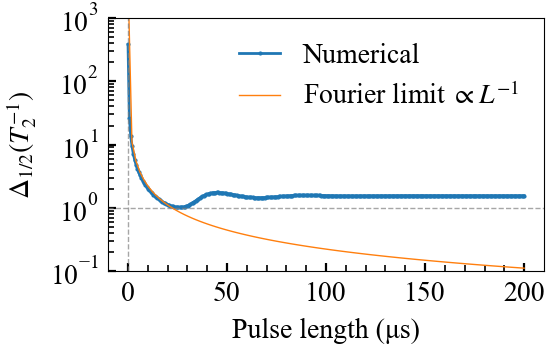

In [27]:
fig, ax = plt.subplots(figsize=(3, 2))

ax.minorticks_on()
ax.yaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=12))
ax.plot(lengths_us, fwhm_measured, marker='.', label='Numerical', linewidth=1, markersize=1)
ax.plot(lengths_us_smooth, A / lengths_us_smooth, label=r'Fourier limit $\propto L^{-1}$')
ax.axhline(1, color='gray', linestyle='--', alpha=0.7)
ax.axvline(0, color='gray', linestyle='--', alpha=0.7)
ax.set_yscale('log')
ax.set_xlabel('Pulse length (μs)')
ax.set_ylabel(r'$\Delta_{1/2} (T_2^{-1})$')
ax.legend()
ax.set_ylim(0.1, 1e3)
fig.tight_layout()
fig.savefig("length_scan.png", dpi=300)
plt.show()
